# 2.2 — Oversampling with Modest Multipliers (No copy_paste)

Retry oversampling with **conservative multipliers** and **no copy_paste augmentation**.

**Strategy:**
- Images containing `no-helmet` (class 1): duplicated **3x** (each copy augmented differently)
- Images containing `no-vest` (class 2): duplicated **2x** (each copy augmented differently)
- All other images kept as-is
- **No `copy_paste`** — only YOLOv8's built-in augmentations (mosaic, flip, HSV, scale, translate)

## Setup

In [1]:
# @title Install dependencies
!pip install -q ultralytics roboflow loguru typer python-dotenv pyyaml matplotlib opencv-python-headless albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 43.6 MB/s eta 0:00:00


In [2]:
# @title Mount Drive or clone repo
import os
from pathlib import Path
import sys

!git clone https://github.com/Hndra04/AlGear
PROJECT_DIR = Path("/content/AlGear")

os.chdir(str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR))
print(f"Project root: {PROJECT_DIR}")

Cloning into 'AlGear'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 112 (delta 9), reused 23 (delta 8), pack-reused 88 (from 1)
Receiving objects: 100% (112/112), 61.82 MiB | 35.13 MiB/s, done.
Resolving deltas: 100% (42/42), done.
Project root: /content/AlGear


In [3]:
# @title Set Roboflow API key
import os
os.environ["ROBOFLOW_API_KEY"] = ""

from algear.config import ROBOFLOW_DIR, ROBOFLOW_API_KEY
print(f"API key set: {bool(ROBOFLOW_API_KEY)}")
print(f"Dataset at: {ROBOFLOW_DIR}")

2026-06-22 14:23:04.327 | INFO     | algear.config:<module>:10 - PROJ_ROOT path is: /content/AlGear


API key set: True
Dataset at: /content/AlGear/data/raw/construction-safety-gsnvb


In [4]:
# @title Download dataset (if not already present)
if not ROBOFLOW_DIR.exists():
    from algear.dataset import download_roboflow
    download_roboflow(output_dir=ROBOFLOW_DIR)
else:
    print(f"Dataset already exists at {ROBOFLOW_DIR}")

2026-06-22 14:23:04.870 | INFO     | algear.dataset:download_roboflow:33 - Downloading roboflow-100/construction-safety-gsnvb v1 to /content/AlGear/data/raw/construction-safety-gsnvb
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/AlGear/data/raw/construction-safety-gsnvb in yolov8:: 100%|██████████| 2424/2424 [00:00<00:00, 6861.51it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2026-06-22 14:23:35.152 | SUCCESS  | algear.dataset:download_roboflow:37 - Dataset downloaded to /content/AlGear/data/raw/construction-safety-gsnvb


## 1. Class Distribution Before Oversampling

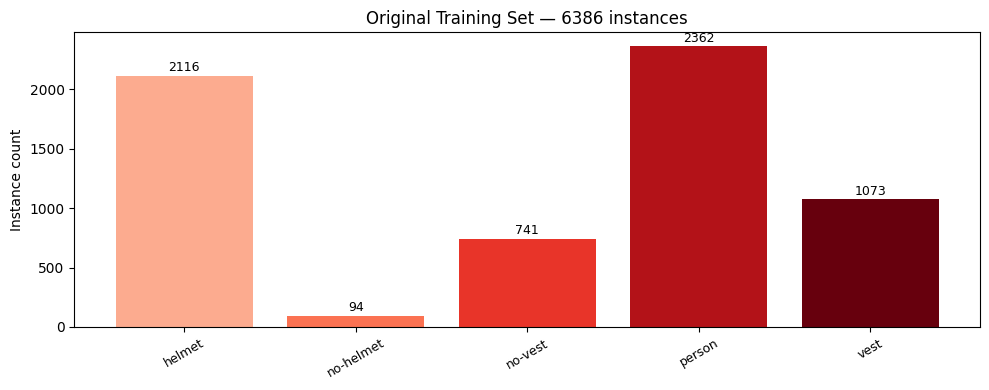

Imbalance ratio (helmet:no-helmet):  22.5x
Imbalance ratio (vest:no-vest):      1.4x


In [5]:
# @title Visualise original class distribution
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import yaml

from algear.config import ROBOFLOW_DIR

with open(ROBOFLOW_DIR / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg["names"]

def count_instances(lbl_dir) -> Counter:
    c = Counter()
    for lbl in sorted(lbl_dir.glob("*.txt")):
        with open(lbl) as f:
            for line in f:
                c[int(line.strip().split()[0])] += 1
    return c

train_counts = count_instances(ROBOFLOW_DIR / "train" / "labels")
total = sum(train_counts.values())

fig, ax = plt.subplots(figsize=(10, 4))
names = [class_names[i] for i in range(len(class_names))]
counts = [train_counts.get(i, 0) for i in range(len(class_names))]
colors = plt.cm.Reds(np.linspace(0.3, 1.0, len(names)))

bars = ax.bar(names, counts, color=colors)
ax.set_title(f"Original Training Set — {total} instances")
ax.set_ylabel("Instance count")
ax.tick_params(axis="x", rotation=30, labelsize=9)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(c), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Imbalance ratio (helmet:no-helmet):  {counts[0] / max(counts[1], 1):.1f}x")
print(f"Imbalance ratio (vest:no-vest):      {counts[4] / max(counts[2], 1):.1f}x")

## 2. Generate Oversampled Dataset

Conservative multipliers: **3x** for `no-helmet`, **2x** for `no-vest`.

Same augmentation types as 2.1 (brightness/contrast, hue/sat, blur, noise, CLAHE, gamma, grayscale) but fewer copies = less repetition of the same images.

In [6]:
# @title Run oversampling (conservative multipliers)
from algear.dataset import oversample

oversample(
    labels_dir=ROBOFLOW_DIR / "train" / "labels",
    img_dir=ROBOFLOW_DIR / "train" / "images",
    output_dir=PROJECT_DIR / "data" / "processed" / "construction-site-safety-oversampled",
    multiplier_no_helmet=3,
    multiplier_no_vest=2,
)

2026-06-22 14:23:35.471 | INFO     | algear.dataset:oversample:85 - Class 1 (no-helmet): 49 images, multiplier=3, ~98 augmented copies
2026-06-22 14:23:35.471 | INFO     | algear.dataset:oversample:85 - Class 2 (no-vest): 390 images, multiplier=2, ~390 augmented copies
2026-06-22 14:23:35.471 | INFO     | algear.dataset:oversample:91 - Creating oversampled dataset in /content/AlGear/data/processed/construction-site-safety-oversampled


Oversampling: 100%|██████████| 997/997 [00:09<00:00, 103.84files/s]

2026-06-22 14:23:46.716 | INFO     | algear.modeling.oversample:create_oversampled_dataset:116 - Oversampling complete: 997 originals + 458 augmented = 1455 total
2026-06-22 14:23:46.720 | SUCCESS  | algear.dataset:oversample:112 - Oversampled dataset ready at /content/AlGear/data/processed/construction-site-safety-oversampled


## 3. Class Distribution After Oversampling

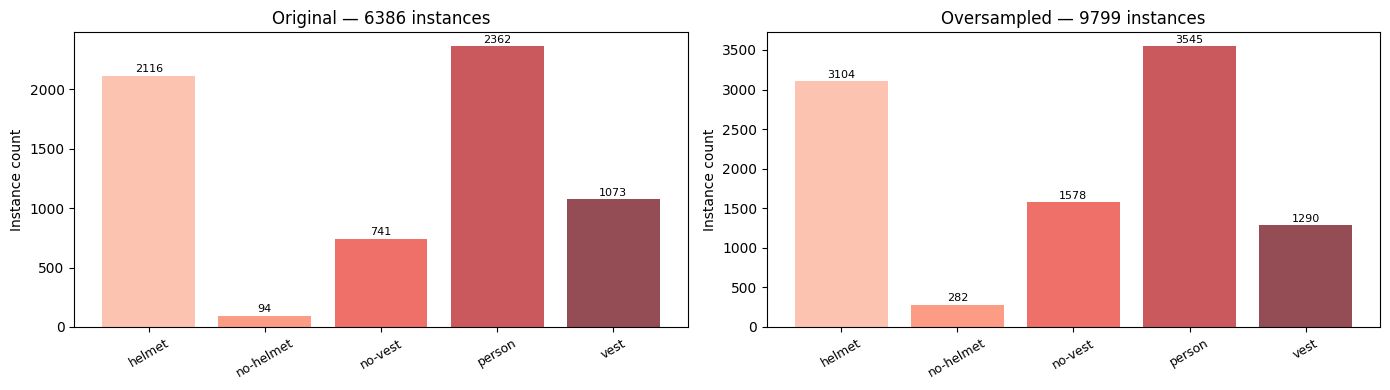

Imbalance ratio (helmet:no-helmet):  11.0x
Imbalance ratio (vest:no-vest):      0.8x


In [7]:
# @title Visualise oversampled class distribution
oversampled_dir = PROJECT_DIR / "data" / "processed" / "construction-site-safety-oversampled"

os_counts = count_instances(oversampled_dir / "train" / "labels")
os_total = sum(os_counts.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

os_counts_list = [os_counts.get(i, 0) for i in range(len(class_names))]

ax1.bar(names, counts, color=colors, alpha=0.7)
ax1.set_title(f"Original — {total} instances")
ax1.set_ylabel("Instance count")
ax1.tick_params(axis="x", rotation=30, labelsize=9)

ax2.bar(names, os_counts_list, color=colors, alpha=0.7)
ax2.set_title(f"Oversampled — {os_total} instances")
ax2.set_ylabel("Instance count")
ax2.tick_params(axis="x", rotation=30, labelsize=9)

for ax, cts in [(ax1, counts), (ax2, os_counts_list)]:
    for bar, c in zip(ax.containers[0], cts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                str(c), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Imbalance ratio (helmet:no-helmet):  {os_counts_list[0] / max(os_counts_list[1], 1):.1f}x")
print(f"Imbalance ratio (vest:no-vest):      {os_counts_list[4] / max(os_counts_list[2], 1):.1f}x")

## 4. Train with Oversampled Data (No copy_paste)

Changes from 2.1:
- Multipliers reduced (3x no-helmet, 2x no-vest vs 10x/3x)
- `copy_paste=0.0` — no object pasting during training
- Only YOLOv8's default augmentations (mosaic, flip, HSV, scale, translate) are active

In [8]:
# @title Train YOLOv8s with conservative oversampling
import torch

device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

from algear.modeling.train import train_yolov8

results = train_yolov8(
    model_name="yolov8s.pt",
    name="oversample-conservative",
    epochs=50,
    imgsz=640,
    batch=16,
    device=device,
    output_dir=PROJECT_DIR / "models",
    oversample_data=True,
    copy_paste=0.0,
)

Using device: 0
GPU: Tesla T4
2026-06-22 14:23:53.724 | INFO     | algear.modeling.train:train_yolov8:37 - Using oversampled dataset: /content/AlGear/data/processed/construction-site-safety-oversampled/data.yaml
2026-06-22 14:23:54.158 | INFO     | algear.modeling.train:train_yolov8:46 - Training YOLOv8s on /content/AlGear/data/processed/construction-site-safety-oversampled/data.yaml
2026-06-22 14:23:54.158 | INFO     | algear.modeling.train:train_yolov8:47 - Epochs=50, imgsz=640, batch=16, device=0
2026-06-22 14:23:54.158 | INFO     | algear.modeling.train:train_yolov8:57 - Imbalance strategies: repeat-factor oversampling
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=

## 5. Evaluate on Test Set

In [10]:
# @title Evaluate best model on test split
from algear.modeling.train import evaluate

import glob
model_dirs = sorted(PROJECT_DIR.glob("models/*/weights/best.pt"))
latest_model = model_dirs[-1] if model_dirs else None
print(f"Evaluating: {latest_model}")

metrics = evaluate(
    model_path=latest_model,
    data_yaml=ROBOFLOW_DIR / "data.yaml",
    split="test",
    device=device,
)

Evaluating: /content/AlGear/models/oversample-conservative/weights/best.pt
2026-06-22 14:51:52.253 | INFO     | algear.modeling.train:evaluate:106 - Evaluating /content/AlGear/models/oversample-conservative/weights/best.pt on test split
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1815.3±780.2 MB/s, size: 61.8 KB)
val: Scanning /content/AlGear/data/raw/construction-safety-gsnvb/test/labels.cache... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 34.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.9it/s 3.2s
                   all         90        623      0.755      0.815      0.762      0.398
                helmet         82        195      0.827      0.928      0.928      0.483
             no-helmet         11         24     

## 6. Results Summary

Compare across all three experiments:

| Class | Baseline (2.0) | 2.1 Oversampled | 2.2 Conservative |
|---|---|---|---|
| helmet | 0.929 | 0.926 | 0.928 |
| no-helmet | 0.592 | 0.583 | 0.483 |
| no-vest | 0.630 | 0.602 | 0.689 |
| person | 0.890 | 0.873 | 0.870 |
| vest | 0.850 | 0.823 | 0.839 |
| **Overall** | **0.778** | **0.761** | **0.762** |